<a href="https://colab.research.google.com/github/Ameena1BM23CS27/6thSem-ML-Lab/blob/main/KNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# Import required libraries
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler

In [1]:
# -------------------------------
# 1. KNN Classifier for IRIS Dataset
# -------------------------------


In [4]:
# Load dataset
iris = pd.read_csv("iris (1).csv")

# Features and target
X_iris = iris.iloc[:, :-1]   # all columns except last
y_iris = iris.iloc[:, -1]    # last column (species)

In [5]:
# Train-test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X_iris, y_iris, test_size=0.2, random_state=42
)

In [6]:
# Create KNN model (k = 5 is commonly used for iris)
knn_iris = KNeighborsClassifier(n_neighbors=5)


In [7]:
# Train model
knn_iris.fit(X_train, y_train)

# Predictions
y_pred_iris = knn_iris.predict(X_test)

# Evaluation
print("----- IRIS DATASET RESULTS -----")
print("Accuracy Score:", accuracy_score(y_test, y_pred_iris))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_iris))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_iris))

----- IRIS DATASET RESULTS -----
Accuracy Score: 1.0

Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [8]:

# -------------------------------
# 2. KNN Classifier for Diabetes Dataset
# -------------------------------


In [9]:
# Load dataset
diabetes = pd.read_csv("diabetes (1).csv")

# Features and target
X_diabetes = diabetes.iloc[:, :-1]
y_diabetes = diabetes.iloc[:, -1]

# Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_diabetes)

# Train-test split
X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(
    X_scaled, y_diabetes, test_size=0.2, random_state=42
)

# Create KNN model (example: k = 7)
knn_diabetes = KNeighborsClassifier(n_neighbors=7)

# Train model
knn_diabetes.fit(X_train_d, y_train_d)

# Predictions
y_pred_diabetes = knn_diabetes.predict(X_test_d)

# Evaluation
print("\n----- DIABETES DATASET RESULTS -----")
print("Accuracy Score:", accuracy_score(y_test_d, y_pred_diabetes))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_d, y_pred_diabetes))

print("\nClassification Report:")
print(classification_report(y_test_d, y_pred_diabetes))


----- DIABETES DATASET RESULTS -----
Accuracy Score: 0.6818181818181818

Confusion Matrix:
[[78 21]
 [28 27]]

Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.79      0.76        99
           1       0.56      0.49      0.52        55

    accuracy                           0.68       154
   macro avg       0.65      0.64      0.64       154
weighted avg       0.67      0.68      0.68       154



In [10]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

Best K value: 6
Accuracy Score: 0.9344262295081968

Confusion Matrix:
 [[28  1]
 [ 3 29]]

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.97      0.93        29
           1       0.97      0.91      0.94        32

    accuracy                           0.93        61
   macro avg       0.93      0.94      0.93        61
weighted avg       0.94      0.93      0.93        61



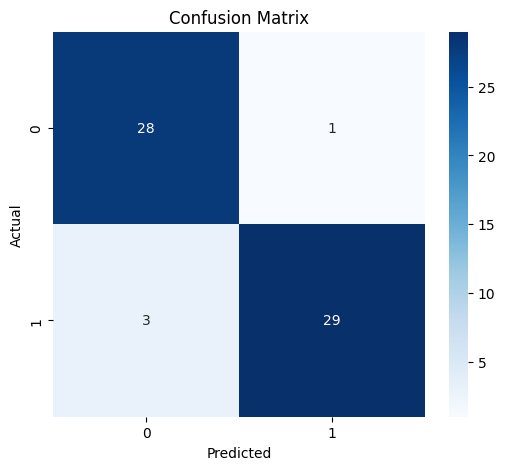

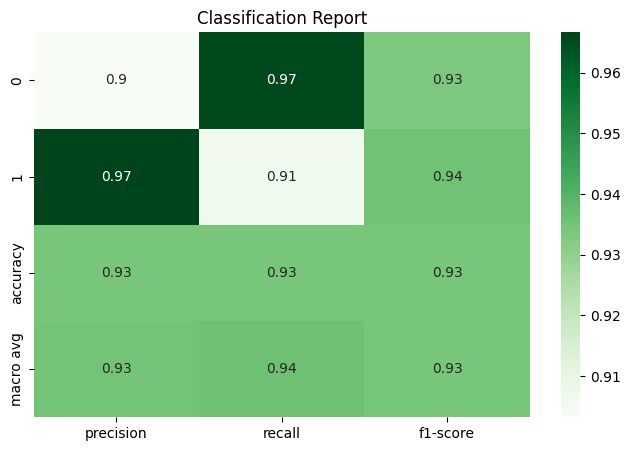

In [11]:
# Load dataset
data = pd.read_csv("heart.csv")

# Separate features and target
X = data.drop("target", axis=1)
y = data["target"]

# Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# Find best K value
scores = []
k_values = range(1, 21)

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    scores.append(accuracy_score(y_test, y_pred))

best_k = k_values[scores.index(max(scores))]
print("Best K value:", best_k)

# Train model with best K
model = KNeighborsClassifier(n_neighbors=best_k)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Accuracy
print("Accuracy Score:", accuracy_score(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)

# Classification Report
report = classification_report(y_test, y_pred)
print("\nClassification Report:\n", report)

# Plot Confusion Matrix
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, cmap="Blues", fmt="d")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Plot Classification Report as Heatmap
report_dict = classification_report(y_test, y_pred, output_dict=True)
report_df = pd.DataFrame(report_dict).transpose()

plt.figure(figsize=(8,5))
sns.heatmap(report_df.iloc[:-1, :-1], annot=True, cmap="Greens")
plt.title("Classification Report")
plt.show()